# Predicting Air Turbulence Using Machine Learning
By: Chee Qian Wen
<br>Feb 25

## Part 5: Modelling
In Part 4, the focus was on exploratory data analyses (EDA). EDA is a crucial step in the machine learning pipeline that involves analyzing and visualizing the data to patterns, trends, and relationships before building models. It helps in identifying the best features to build the machine learning model. In Part 4 the key features identified include: Location, meteorological data, aircraft weight, time of day, and season. 

Part 5 involves building several machine learning models based on these features. The objective is to identify which model gives the highest accuracy (ideally above 90%).

### 5.1. Import Libraries
First, the necessary libraries are imported.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from catboost import CatBoostClassifier

In [4]:
df = pd.read_csv('cleaned_data.csv')

In [5]:
df = df.drop('Unnamed: 0', axis=1)

### 5.2. Model Pre-processing
In this section, we will walk through the essential steps required to prepare our dataset for modeling. The following sections will remove outliers, check for multicollinearity, and create the train-test split for machine learning.

#### 5.2.1. Feature scaling
First, all numeric features in the dataset are scaled. Feature scaling is crucial for ML models to ensure that all features contribute equally to the model's performance. Additionally, feature scaling aids in faster convergence during optimization processes, improving model training times and performance. Lastly, feature scaling allows for regression coefficients to be compared and interpreted.

In [7]:
# scale features
columns_to_scale = ['FL','ELEV','MAX_TEMP','MIN_TEMP','WIND','WIND_DRCT','HUM','DISTANCE_TO_GROUND','TURB_DEG'] 
scaler = StandardScaler()

df[columns_to_scale] = scaler.fit_transform(df[columns_to_scale])

#### 5.2.2. Removal of outliers
Outliers can skew the model's performance and lead to inaccurate predictions. This section detects and removes outliers from the dataset based on features with z-score (number of standard deviations away from the mean) of less than -3.0 or more than 3.0.

In [9]:
# screen for outliers
# Keep rows where all specified columns are within the range [-3, 3]
df = df[(df[columns_to_scale] >= -3).all(axis=1) & (df[columns_to_scale] <= 3).all(axis=1)]

#### 5.2.3. Check for multicollinearity
Multicollinearity occurs when features in the dataset are highly correlated. This can negatively impact the model's interpretability and performance. This section uses a correlation matrix and Pearson's <i>r</i> to identify and address multicollinearity.

If any of the features are highly correlated with other features (<i>r</i> > .7), only one can be included during feature selection.

In [11]:
corr_matrix = df.select_dtypes(include=[np.number]).corr() 

multicollinearity_detected = False 

# check if any values in the correlation matrix exceeds 0.7
# returns pair(s) of values that have a correlation above 0.7
for col in corr_matrix.columns: 
    for row in corr_matrix.index: 
        if row != col and abs(corr_matrix.loc[row, col]) > 0.7: 
            print(f"The correlation between {row} and {col} is {corr_matrix.loc[row, col]}.") 
            multicollinearity_detected = True 

if multicollinearity_detected == False: 
    print("No multicollinearity detected.")

The correlation between DISTANCE_TO_GROUND and FL is 0.9806505067657167.
The correlation between MIN_TEMP and MAX_TEMP is 0.8614877876824291.
The correlation between MAX_TEMP and MIN_TEMP is 0.8614877876824291.
The correlation between FL and DISTANCE_TO_GROUND is 0.9806505067657167.


#### 5.2.4. Feature selection
In this section, features are selected to include in the model. Feature selection is the process of identifying and selecting the most relevant features in a dataset that contribute significantly to the model's predictive power. It helps in reducing the dimensionality of the data, improving model performance, and making the model more interpretable by focusing on the most impactful features.

Features that have been identified as potentially strong predictors air turbulence based on the EDA in Part 4 are included.

In [59]:
# specify feature columns for modelling
feature_cols = ['LAT','LON','SEASON_Summer','TIME_OF_DAY_Sunrise',
                'STATE_Texas','MAX_TEMP','WIND','ELEV','FL']
X = df[feature_cols]
y = df['TURB']

In [61]:
if y.dtype == 'object':
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y) 

#### 5.2.5. Create train-test split
Splitting the dataset into training and testing sets is essential to evaluate the model's performance on unseen data. A train-test split is used to split the dataset into 75% data for training and 25% data for testing.

In [63]:
# create train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=99)

### 5.3. Build Machine Learning Models
In this section, the ML models are built and evaluated. The aim of these ML models is to classify the degree of turbulence into one of these categories: LIGHT, MODERATE, or SEVERE. The use of ML models enables computers to learn from the dataset and make predictions by identifying patterns in the dataset.

4 ML models will be built and evaluated:

**1) Decision Tree Classifier**<br>
**2) Random Forest Classifier**<br>
**3) XGBoost Classifier**<br>
**4) CatBoost Classifier**

80% accuracy will be used as baseline metric to evaluate the performance of the ML models. This baseline will determine if the models are performing well or if further optimization is needed. 

After each model has been built, feature importance will be examined to determine which features have the most significant impact on the model's predictions. Based on the results of the models, backward selection will be performed iteratively to identify the features that give the best performing models.

#### 5.3.1. Decision Tree
A decision tree splits the data into subsets based on the most significant features. Decision trees are easy to interpret and visualize but can easily overfit the training data if not pruned properly.

- **Speed**: Fast
- **Accuracy**: Moderate
- **Overfitting**: High, if not pruned

In [65]:
%%time
# calculate runtime

model = DecisionTreeClassifier(random_state=99)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
train_accuracy = accuracy_score(y_pred_train, y_train)
    
print(f"Train accuracy: {train_accuracy}")

y_pred_test = model.predict(X_test)
test_accuracy = accuracy_score(y_pred_test, y_test)
    
print(f"Test accuracy: {test_accuracy}")

Train accuracy: 0.9965987009932517
Test accuracy: 0.6984314252006067
CPU times: total: 20.6 s
Wall time: 21.5 s


Precision (Macro-Averaged): 0.3766848432878791
Recall (Macro-Averaged): 0.3831667349965535


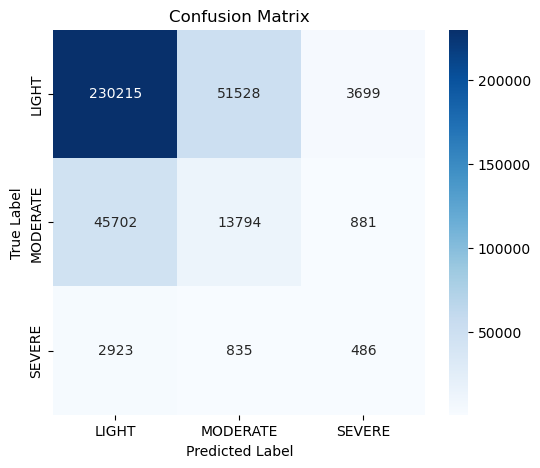

In [66]:
precision = precision_score(y_test, y_pred_test, average='macro')  # 'macro' for multiclass
recall = recall_score(y_test, y_pred_test, average='macro')  # 'macro' for multiclass

# Print results
print(f"Precision (Macro-Averaged): {precision:}")
print(f"Recall (Macro-Averaged): {recall:}")

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", 
            xticklabels=["LIGHT", "MODERATE", "SEVERE"], 
            yticklabels=["LIGHT", "MODERATE", "SEVERE"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

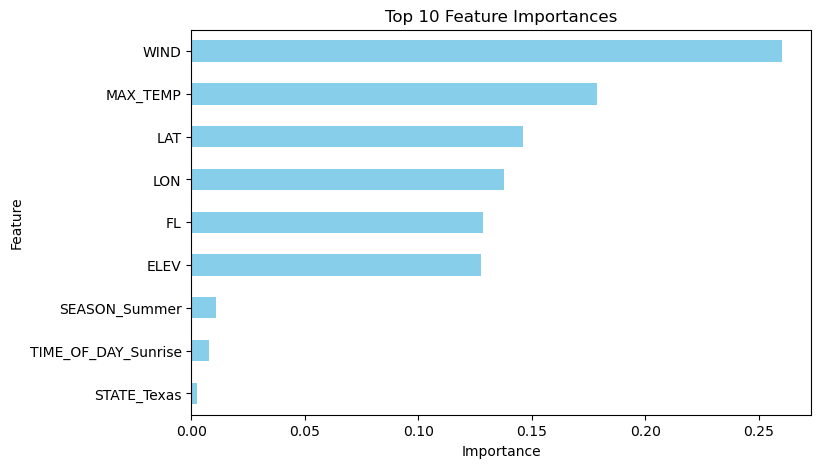

In [67]:
# Get feature importances and sort in descending order
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)  # Sort in descending order

# Plot only the top 10 features
feat_importances.head(10).plot(kind='barh', figsize=(8, 5), color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()

#### 5.3.2. Random Forest

In [69]:
%%time
# calculate runtime

model = RandomForestClassifier(n_estimators=50, max_depth = 10, min_samples_leaf = 1, min_samples_split = 5)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
train_accuracy = accuracy_score(y_pred_train, y_train)
    
print(f"Train accuracy: {train_accuracy}")

y_pred_test = model.predict(X_test)
test_accuracy = accuracy_score(y_pred_test, y_test)
    
print(f"Test accuracy: {test_accuracy}")

Train accuracy: 0.8167278779874442
Test accuracy: 0.8157988704890262
CPU times: total: 1min 50s
Wall time: 1min 55s


Precision (Macro-Averaged): 0.4525704681361857

C:\Users\qianw\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Recall (Macro-Averaged): 0.33699118319422405


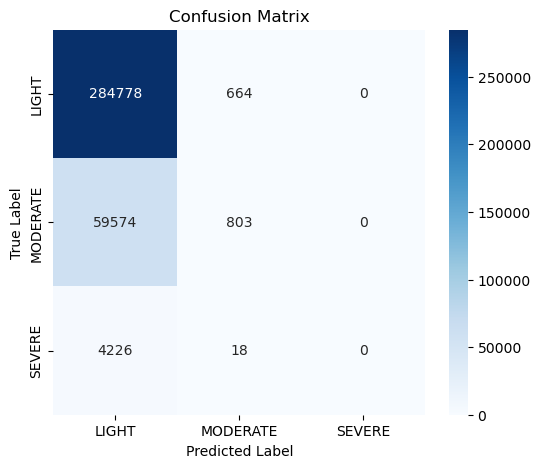

In [70]:
precision = precision_score(y_test, y_pred_test, average='macro')  # 'macro' for multiclass
recall = recall_score(y_test, y_pred_test, average='macro')  # 'macro' for multiclass

# Print results
print(f"Precision (Macro-Averaged): {precision:}")
print(f"Recall (Macro-Averaged): {recall:}")

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", 
            xticklabels=["LIGHT", "MODERATE", "SEVERE"], 
            yticklabels=["LIGHT", "MODERATE", "SEVERE"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

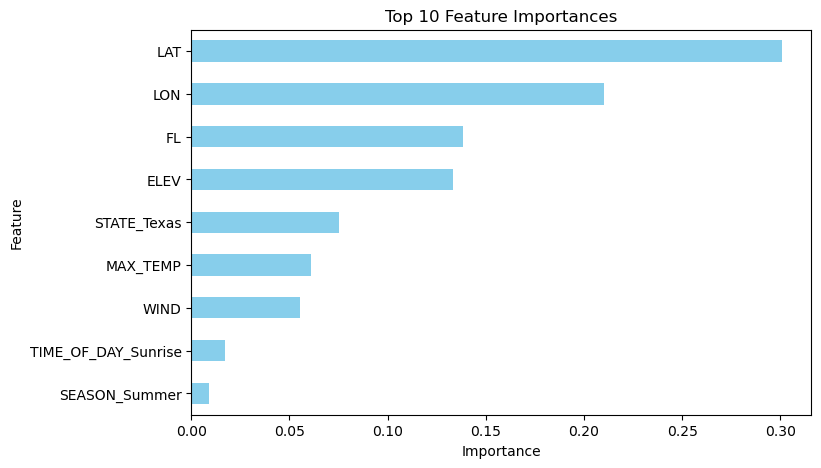

In [71]:
# Get feature importances and sort in descending order
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)  # Sort in descending order

# Plot only the top 10 features
feat_importances.tail(10).plot(kind='barh', figsize=(8, 5), color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()

#### 5.3.3. XGBoost
XGBoost (Extreme Gradient Boosting) is an advanced implementation of gradient boosting that excels in both speed and accuracy. It is particularly well-suited for structured/tabular data. XGBoost offers regularization to prevent overfitting.

- **Speed**: Fast (with optimizations)
- **Accuracy**: High
- **Overfitting**: Reduced with built-in regularization

In [73]:
%%time
# calculate runtime

# train and fit model
model = xgb.XGBClassifier(max_depth = 7, learning_rate = 0.1, n_estimators = 500)

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
train_accuracy = accuracy_score(y_pred_train, y_train)
    
print(f"Train accuracy: {train_accuracy}")

y_pred_test = model.predict(X_test)
test_accuracy = accuracy_score(y_pred_test, y_test)
    
print(f"Test accuracy: {test_accuracy}")

Train accuracy: 0.8185237486276253
Test accuracy: 0.8157931572316983
CPU times: total: 5min 13s
Wall time: 1min 28s


Precision (Macro-Averaged): 0.613535476402664
Recall (Macro-Averaged): 0.33921891422849243


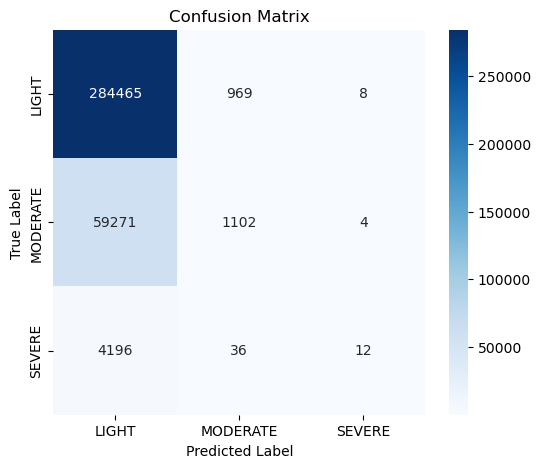

In [74]:
precision = precision_score(y_test, y_pred_test, average='macro')  # 'macro' for multiclass
recall = recall_score(y_test, y_pred_test, average='macro')  # 'macro' for multiclass

# Print results
print(f"Precision (Macro-Averaged): {precision:}")
print(f"Recall (Macro-Averaged): {recall:}")

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", 
            xticklabels=["LIGHT", "MODERATE", "SEVERE"], 
            yticklabels=["LIGHT", "MODERATE", "SEVERE"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

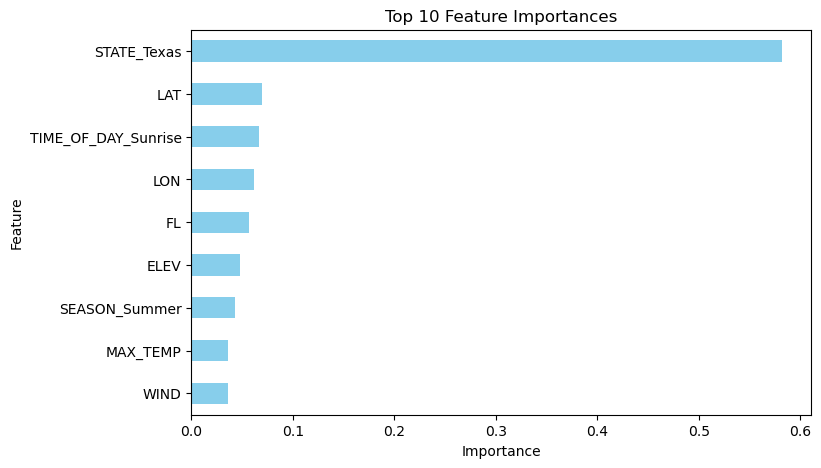

In [75]:
# Get feature importances and sort in descending order
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)  # Sort in descending order

# Plot only the top 10 features
feat_importances.head(10).plot(kind='barh', figsize=(8, 5), color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()

####  5.3.4. CatBoost
CatBoost is a gradient boosting algorithm that offers high accuracy and is less prone to overfitting compared to other boosting methods. CatBoost provides robust performance across various types of data.

- **Speed**: Moderate (with categorical features)
- **Accuracy**: High
- **Overfitting**: Reduced with built-in techniques

In [77]:
%%time
# calculate runtime

# train and fit model
model = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6, verbose=False)

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
train_accuracy = accuracy_score(y_pred_train, y_train)
    
print(f"Train accuracy: {train_accuracy}")

y_pred_test = model.predict(X_test)
test_accuracy = accuracy_score(y_pred_test, y_test)
    
print(f"Test accuracy: {test_accuracy}")

Train accuracy: 0.8166269435824286
Test accuracy: 0.8157303114010906
CPU times: total: 14min 1s
Wall time: 3min 54s


Precision (Macro-Averaged): 0.44608420035093116
Recall (Macro-Averaged): 0.3379251886129582


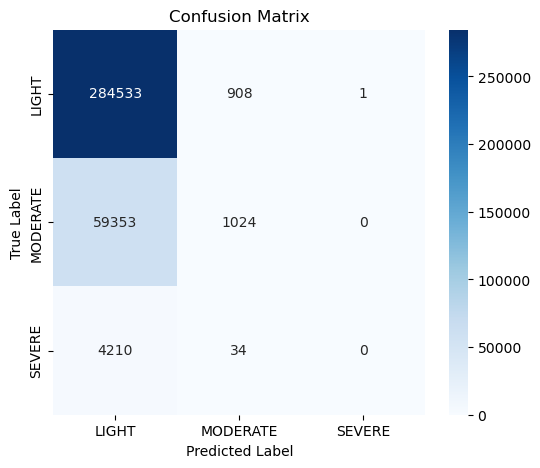

In [78]:
precision = precision_score(y_test, y_pred_test, average='macro')  # 'macro' for multiclass
recall = recall_score(y_test, y_pred_test, average='macro')  # 'macro' for multiclass

# Print results
print(f"Precision (Macro-Averaged): {precision:}")
print(f"Recall (Macro-Averaged): {recall:}")

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues", 
            xticklabels=["LIGHT", "MODERATE", "SEVERE"], 
            yticklabels=["LIGHT", "MODERATE", "SEVERE"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

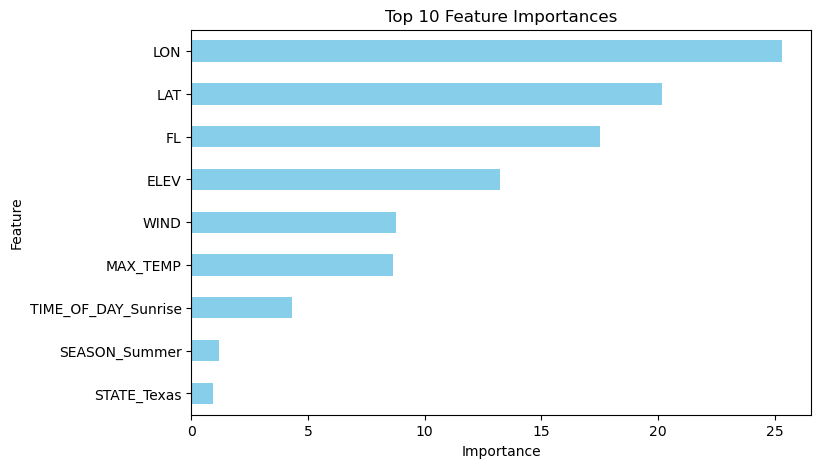

In [79]:
# Get feature importances and sort in descending order
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances = feat_importances.sort_values(ascending=False)  # Sort in descending order

# Plot only the top 10 features
feat_importances.head(10).plot(kind='barh', figsize=(8, 5), color='skyblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()

## 6. Conclusion and Recommendations

Across the 5 notebooks, data was extracted and imported to examine the influence of various features on air turbulence. Various ML models were built to predict air turbulence based on these features. By evaluating the trade-offs between train and test accuracy, model discrepancies, and runtime, **Random Forest** has been identified as the best model.

The following table summarizes the performance of the models evaluated:
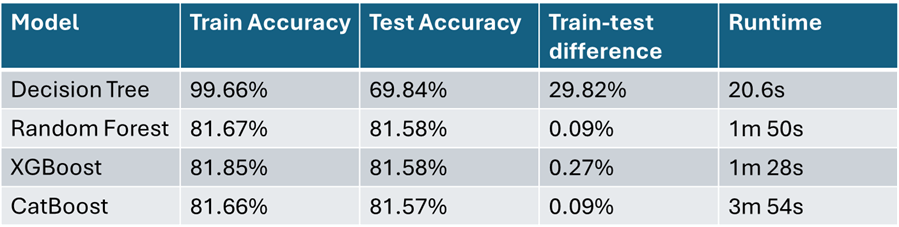

Random Forest demonstrated superior performance with a high train and test accuracy, while maintaining a reasonable runtime. Importantly, this model exhibits no significant overfitting and surpassed the baseline metric of 80% accuracy.

Across the models, the strongest predictors air turbulence were identified as:
- **Location (state)**
- **Longitude, Latitude**
- **Season**
- **Time of Day**
- **Wind Speed**
- **Temperature**
- **Ground Elevation**
- **Flight Level**

Predicting air turbulence is highly valuable to all stakeholders in aviation. *Passengers* benefit from a smoother, more comfortable flight with advance warnings, enhancing satisfaction and reducing anxiety. *Airlines* can optimize flight routes, improve fuel efficiency, reduce delays, and lower the risk of injuries, leading to cost savings and better operational performance. *Pilots* gain the ability to adjust flight paths or altitudes to avoid turbulent areas, enhancing safety and efficiency. *Air traffic controllers (ATC)* can better manage air traffic flow by routing aircraft away from turbulent zones, ensuring safer separation and minimizing congestion. In essence, turbulence prediction improves safety, efficiency, and overall experience for everyone involved.

By harnessing the power of machine learning, this model offers a comprehensive and data-driven approach to understanding and predicting air turbulence. 